In [ ]:
import sys
sys.path.insert(0, '..')

In [1]:
from utils.dynamicRieszFunctions import estimateDynamicRiesz_all
from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiDLinear import estimateDiDLinear
import torch
import pandas as pd
import time
from torch.distributions import Normal
from utils.dgp import DiD_DGP
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


## Settings


In [2]:
lasso_cv_settings = {
    'b_degree' : 1,
    'cv_folds' : 5,
    'random_state' : 42
}

lasso_a_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' : "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

lasso_f_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' :  "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

rf_a_settings = {
    'poly_degree' : 0,
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' :1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}
rf_f_settings = {
    'poly_degree' : 1, # 1 or 2?
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' :1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}

net_a_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}

net_f_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}


## Coefficients and Parameters

In [3]:
# Parameters
N = 1000
tmax = 1
dimX = 3
dimZ = 2
seed = 123
folds = 5

## Propensity models 

In [4]:
# Bounds (only for truncated distributions)
lower = 0.30
upper = 0.70

# Define logistic function
def logistic(x):
    return torch.exp(x) / (1 + torch.exp(x))

# Define a truncated logistic function
def truncated_logistic(x):
    return lower + (upper - lower) * logistic(x)

# Simple nonlinear probability (from adversarial Riesz paper)
def truncated_adv(x):
    return lower + (upper - lower) * (x > 0)


## Generate data

In [5]:
dgp = DiD_DGP(dim_X=dimX, dim_Z=dimZ, 
                alpha_1 = 1, # Y_1s effect on D
              gamma_1=torch.ones(dimZ), # Z effect on D
                gamma_2=torch.ones(dimZ), # Z effect on Y
                g = truncated_logistic, # specification of the propensity modek
                beta_2=2,
                delta_3= 2 
                )

data = dgp.generate(n =N*tmax, seed = seed)
X1 = data['X1']
X2 = data['X2']
Y1 = data['Y1']
Y2 = data['Y2']
Z = data['Z']
D = data['D']


In [6]:
ATT_calculations = dgp.simulate_ATT(n = 100000000)


In [7]:
ATT_calculations["ATT"]

tensor(3.9224)

In [8]:
print(X1.shape)
print(X2.shape)
print(Y1.shape)
print(Y2.shape)
print(Z.shape)
print(D.shape)

torch.Size([1000, 3])
torch.Size([1000, 3])
torch.Size([1000])
torch.Size([1000])
torch.Size([1000, 2])
torch.Size([1000])


In [9]:
print(D.mean())

tensor(0.5270)


In [10]:
# Naive ATT estimate
Y2[D==1].mean() - Y2[D==0].mean()

tensor(5.9345)

## Estimation

In [ ]:
time0 = time.time()
pred_theta = torch.zeros(tmax,5)
pred_sig = torch.zeros(tmax,5)

RR1 = torch.zeros(N,tmax,5)
RR2 = torch.zeros(N,tmax,5)
f1 = torch.zeros(N,tmax,5)
f2 = torch.zeros(N,tmax,5)

for t in tqdm(range(0,1)):

    # Get data for current iteration
    X1_sub = X1[t*N:(t+1)*N,:]
    X2_sub = X2[t*N:(t+1)*N,:]
    Y1_sub = Y1[t*N:(t+1)*N].view(-1, 1)
    Y2_sub = Y2[t*N:(t+1)*N].view(-1, 1)
    D_sub = D[t*N:(t+1)*N].view(-1, 1)
    Z_sub = Z[t*N:(t+1)*N,:]


    pred_theta[t,1], pred_sig[t,1] = estimateDiDLinear(Y1_sub, Y2_sub, D_sub, Z_sub, X1_sub  , X2_sub)

    pred_theta[t,3], pred_sig[t,3], RR1[:,t,3:4], RR2[:,t,3:4] = estimateDynamicRiesz(Y1_sub, Y2_sub, D_sub, Z_sub, X1_sub  , X2_sub, folds,
                                                                     method_a = "LASSO", rf_a_settings=rf_a_settings,
                                                                        method_f = "LASSO", rf_f_settings = rf_f_settings)





  0%|          | 0/1 [00:00<?, ?it/s]


RuntimeError: Tensors must have same number of dimensions: got 2 and 1

In [ ]:
pred_theta[:,3] 

tensor([3.8598, 3.8540, 3.8704, 3.8123, 4.3140, 3.9064, 3.6713, 3.8285, 3.9508,
        3.9780, 3.9125, 4.0954, 4.0337, 4.0127, 3.8710, 3.8233, 4.1461, 4.0075,
        4.1368, 3.8637, 3.9644, 3.8450, 3.8587, 3.9399, 3.7216, 4.0302, 3.7746,
        4.2124, 3.8456, 3.9709, 4.0843, 3.5652, 3.5887, 4.1017, 3.8240, 3.9722,
        4.0305, 3.9221, 3.9498, 4.0922, 3.7351, 3.3836, 3.8291, 3.6283, 3.9552,
        4.2668, 4.0514, 3.9286, 3.7694, 3.8570, 4.1318, 3.7572, 3.9393, 3.8837,
        4.1910, 3.8638, 4.0506, 4.1106, 3.8433, 3.3220, 3.8473, 3.8257, 4.0433,
        4.3048, 3.7562, 3.9056, 3.9029, 3.7281, 3.9830, 4.0013, 4.1334, 4.1132,
        3.9170, 3.6666, 3.7754, 4.2014, 3.6926, 4.0690, 3.9683, 4.2869, 4.1106,
        4.0878, 3.8884, 4.0207, 4.3603, 3.9984, 4.0723, 3.7777, 3.7983, 3.9852,
        3.9129, 3.9941, 3.7735, 3.9617, 3.8295, 4.1406, 4.0260, 3.8794, 3.7572,
        3.6517])

In [ ]:
pred_theta[:,1] 

tensor([3.7798, 3.7359, 3.8935, 3.8171, 4.2118, 3.8457, 3.6318, 3.7715, 3.8230,
        3.8333, 3.8901, 4.0291, 3.9607, 3.9966, 3.8732, 3.8175, 3.9761, 3.9980,
        4.0925, 3.7948, 3.9495, 3.8486, 3.8249, 3.8141, 3.7109, 3.9764, 3.7610,
        4.1090, 3.8348, 3.9056, 4.0746, 3.4637, 3.5449, 3.9774, 3.8020, 3.9266,
        4.0369, 3.8518, 3.9032, 4.0074, 3.6061, 3.2947, 3.7652, 3.5828, 3.8835,
        4.1011, 3.9776, 3.8556, 3.7483, 3.7828, 4.1204, 3.6783, 3.9331, 3.7421,
        4.0680, 3.7325, 3.8163, 4.0681, 3.8130, 3.2758, 3.7855, 3.6774, 3.9861,
        4.2114, 3.6767, 3.8496, 3.8579, 3.6114, 3.8675, 3.8921, 3.9934, 3.8140,
        3.8740, 3.5382, 3.7910, 4.0769, 3.6741, 4.0578, 3.8428, 4.1942, 4.1026,
        4.0116, 3.7589, 3.9640, 4.2477, 3.9239, 3.9142, 3.7608, 3.7828, 3.9717,
        3.8898, 3.9469, 3.7327, 3.9098, 3.8332, 4.0832, 3.9274, 3.8717, 3.6403,
        3.6569])

In [ ]:
print(torch.sqrt(torch.mean((pred_theta[:,3] - ATT_calculations["ATT"])**2)))

tensor(0.1828)


In [ ]:
print(torch.sqrt(torch.mean((pred_theta[:,1] - ATT_calculations["ATT"])**2)))

tensor(0.1860)


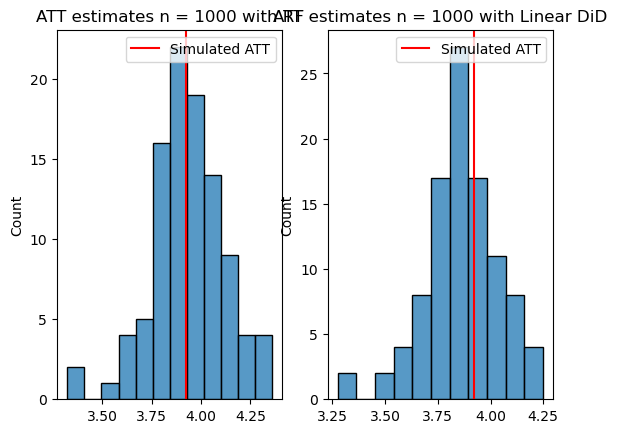

In [ ]:
fig, ax = plt.subplots(1,2)
sns.histplot(pred_theta[:, 3], ax = ax[0])
ax[0].axvline(x=ATT_calculations["ATT"], color="red", label="Simulated ATT")
ax[0].set_title("ATT estimates n = 1000 with RF")
ax[0].legend()#
sns.histplot(pred_theta[:, 1], ax = ax[1])
ax[1].axvline(x=ATT_calculations["ATT"], color="red", label="Simulated ATT")
ax[1].set_title("ATT estimates n = 1000 with Linear DiD")
ax[1].legend()#
plt.show()

## Application

In [ ]:
ATTs, STDs = [], []

for i in tqdm(range(10)):
   data_dict = data_apllication.get_data(2003, 2004, baseline_2001=False)
   X1 = data_dict['X1']
   X2 = data_dict['X2']
   Y1 = data_dict['Y1']
   Y2 = data_dict['Y2']
   Z = data_dict['Z']
   D = data_dict['D']
   ATT, STD, *_ = estimateDynamicRiesz(Y1, Y2, D, Z, X1, X2, folds,
                                                                        method_a = "RF", rf_a_settings=rf_a_settings,
                                                                           method_f = "RF", rf_f_settings = rf_f_settings)
   ATTs.append(ATT)
   STDs.append(STD)
print("ATT: " ,ATT, f"({STD})")

  0%|          | 0/10 [00:00<?, ?it/s]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


 10%|█         | 1/10 [01:46<16:02, 106.97s/it]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


 20%|██        | 2/10 [03:35<14:23, 107.92s/it]

...

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


 90%|█████████ | 9/10 [15:56<01:45, 105.67s/it]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


100%|██████████| 10/10 [17:42<00:00, 106.24s/it]

ATT:  tensor(-0.0089) (0.7864906191825867)


In [ ]:
ATTs

[tensor(-0.0063),
 tensor(-0.0117),
 tensor(-0.0049),
 tensor(-0.0086),
 tensor(-0.0093),
 tensor(-0.0093),
 tensor(-0.0066),
 tensor(-0.0119),
 tensor(-0.0063),
 tensor(-0.0089)]

In [ ]:
import numpy as np
np.mean(ATTs)

-0.008383706

In [ ]:
ATTs, STDs = [], []

for i in tqdm(range(10)):
   data_dict = data_apllication.get_data(2003, 2004, baseline_2001=True)
   X1 = data_dict['X1']
   X2 = data_dict['X2']
   Y1 = data_dict['Y1']
   Y2 = data_dict['Y2']
   Z = data_dict['Z']
   D = data_dict['D']
   ATT, STD, *_ = estimateDynamicRiesz(Y1, Y2, D, Z, X1, X2, folds,
                                                                        method_a = "RF", rf_a_settings=rf_a_settings,
                                                                           method_f = "RF", rf_f_settings = rf_f_settings)
   ATTs.append(ATT)
   STDs.append(STD)
print("ATT: " ,ATT, f"({STD})")

  0%|          | 0/10 [00:00<?, ?it/s]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
2491 2491
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8', '2001_emp0A01_BS', '2001_pop', '2001_annual_avg_pay', '2001_lpop', '2001_lavg_pay']


 10%|█         | 1/10 [04:20<39:04, 260.53s/it]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
2491 2491
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8', '2001_emp0A01_BS', '2001_pop', '2001_annual_avg_pay', '2001_lpop', '2001_lavg_pay']


 20%|██        | 2/10 [08:44<34:59, 262.41s/it]

...

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
2491 2491
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8', '2001_emp0A01_BS', '2001_pop', '2001_annual_avg_pay', '2001_lpop', '2001_lavg_pay']


 90%|█████████ | 9/10 [39:15<04:21, 261.56s/it]

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
2491 2491
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8', '2001_emp0A01_BS', '2001_pop', '2001_annual_avg_pay', '2001_lpop', '2001_lavg_pay']


100%|██████████| 10/10 [43:36<00:00, 261.68s/it]

ATT:  tensor(0.0058) (0.7258304357528687)


In [ ]:
np.mean(ATTs)

0.007205895

In [ ]:
ATTs

[tensor(0.0055),
 tensor(0.0080),
 tensor(0.0104),
 tensor(0.0089),
 tensor(0.0079),
 tensor(0.0045),
 tensor(0.0036),
 tensor(0.0072),
 tensor(0.0102),
 tensor(0.0058)]